<a href="https://colab.research.google.com/github/changyunyeong/MachineLearning_2026_01/blob/main/ML%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_7%E1%84%8C%E1%85%A1%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 실습 - 차원 축소 (Dimensionality Reduction)

고차원 데이터에서 더 적은 수의 차원으로 정보를 압축하면서 원본의 구조를 최대한 보존하는 기법

**왜 차원 축소가 필요한가?**
- 시각화 (Visualization)
- 노이즈 제거 (Noise removal)
- 통계적 상관성 제거 (Removing statistical correlation)
- 효율적인 계산 (More efficient uses)
- 더 나은 거리/유사도 측정 (Better similarity or distance measures)

**차원의 저주 (Curse of dimensionality):** 변수가 너무 많아지면 데이터가 희소해지고 거리 계산이 무의미해짐


In [1]:
# 공통 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

# Part 1. Principal Component Analysis (PCA)

PCA는 데이터의 분산이 최대가 되는 방향(주성분)을 찾아 직교 투영하는 차원 축소 기법

■ 핵심 개념
- 원본 변수들의 **선형 결합(linear combination)**으로 새로운 변수(주성분)를 만듦
- 새로 만들어진 주성분들은 서로 **직교(uncorrelated)**
- 1st PC = 데이터의 **분산이 가장 큰 방향**
- 2nd PC = PC1과 직교하면서 그 다음으로 분산이 큰 방향

■ 수식 정의

데이터 행렬 $X \in \mathbb{R}^{n \times d}$ (n: 샘플 수, d: feature 수)

데이터 센터링: $X \leftarrow X - \bar{X}$

공분산 행렬: $C = \frac{1}{n-1} X^T X$

최적화 문제 (분산 최대화):

$$\max_{v} \, v^T X^T X v \quad \text{s.t.} \quad v^T v = 1$$

라그랑주 승수법으로 풀면:

$$L(v, \lambda) = \frac{1}{n-1} v^T X^T X v - \lambda(v^T v - 1)$$

$\frac{\partial L}{\partial v} = 0$ 으로부터 결국 **고유값 문제(Eigen problem)** 가 됨:

$$Cv = \lambda v$$

→ 주성분 = 공분산 행렬의 **고유벡터**, 고유값이 큰 순서대로 정렬


## ■ Toy example (수작업: 공분산 행렬 → 고유값 분해)

10개 샘플, 2개 feature로 직접 계산해보자.

In [2]:
# 가상의 2차원 데이터
data = {
    'X1': [2.5, 0.5, 2.2, 1.9, 3.1, 2.3, 2.0, 1.0, 1.5, 1.1],
    'X2': [2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9]
}
df = pd.DataFrame(data)
print("--- 원본 데이터 ---")
display(df)

# 1. 데이터 센터링 (평균을 0으로)
X = df.values
X_centered = X - X.mean(axis=0)
print(f"\n각 변수 평균: {X.mean(axis=0)}")

# 2. 공분산 행렬: C = (1/(n-1)) * X^T X
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)
print("\n--- 공분산 행렬 (수작업) ---")
print(cov_matrix)

# 검증
print("\n--- np.cov() 결과 (검증) ---")
print(np.cov(X.T))

--- 원본 데이터 ---


,X1,X2
0,2.5,2.4
1,0.5,0.7
2,2.2,2.9
3,1.9,2.2
4,3.1,3.0
5,2.3,2.7
6,2.0,1.6
7,1.0,1.1
8,1.5,1.6
9,1.1,0.9



각 변수 평균: [1.81 1.91]

--- 공분산 행렬 (수작업) ---
[[0.61655556 0.61544444]
 [0.61544444 0.71655556]]

--- np.cov() 결과 (검증) ---
[[0.61655556 0.61544444]
 [0.61544444 0.71655556]]


In [3]:
# 3. 고유값 분해
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 4. 고유값이 큰 순서대로 정렬
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"--- 정렬된 고유값 ---\n{eigenvalues}")
print(f"\n--- 정렬된 고유벡터 (열이 PC1, PC2) ---\n{eigenvectors}")

# 5. PC score (Projection): X_pca = X_centered @ V
X_pca = X_centered @ eigenvectors
print(f"\n--- 투영 결과 (PC1, PC2) ---")
display(pd.DataFrame(X_pca, columns=['PC1', 'PC2']))

# 6. Explained variance ratio
explained_var = eigenvalues / eigenvalues.sum()
print(f"\n--- 분산 설명력 (Explained Variance Ratio) ---")
print(f"PC1: {explained_var[0]:.4f}, PC2: {explained_var[1]:.4f}")

--- 정렬된 고유값 ---
[1.28402771 0.0490834 ]

--- 정렬된 고유벡터 (열이 PC1, PC2) ---
[[-0.6778734  -0.73517866]
 [-0.73517866  0.6778734 ]]

--- 투영 결과 (PC1, PC2) ---


,PC1,PC2
0,-0.827970,-0.175115
1,1.777580,0.142857
2,-0.992197,0.384375
3,-0.274210,0.130417
4,-1.675801,-0.209498
5,-0.912949,0.175282
6,0.099109,-0.349825
7,1.144572,0.046417
8,0.438046,0.017765
9,1.223821,-0.162675



--- 분산 설명력 (Explained Variance Ratio) ---
PC1: 0.9632, PC2: 0.0368


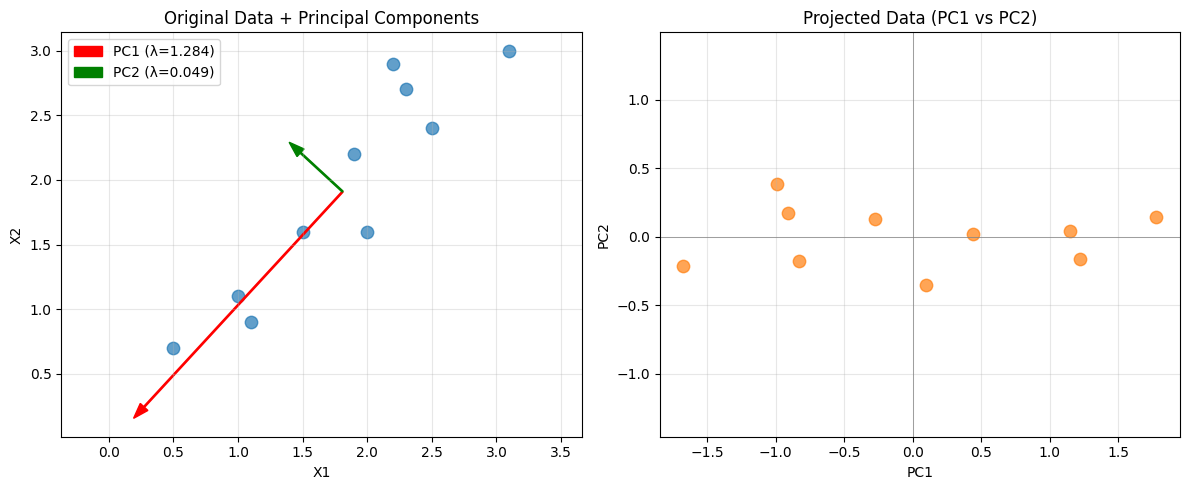

In [4]:
# 원본 데이터 + 주성분 방향 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.7, s=80)
mean_X = X.mean(axis=0)
colors = ['red', 'green']
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    axes[0].arrow(mean_X[0], mean_X[1],
                  vec[0]*np.sqrt(val)*2, vec[1]*np.sqrt(val)*2,
                  head_width=0.08, color=colors[i], width=0.01,
                  label=f'PC{i+1} (λ={val:.3f})')
axes[0].set_title('Original Data + Principal Components')
axes[0].set_xlabel('X1'); axes[0].set_ylabel('X2')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].axis('equal')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=80, color='C1')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].axvline(0, color='gray', lw=0.5)
axes[1].set_title('Projected Data (PC1 vs PC2)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3); axes[1].axis('equal')

plt.tight_layout()
plt.show()

## ■ Sklearn PCA 사용 예제

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X)

print("--- Sklearn PCA 결과 ---")
display(pd.DataFrame(X_pca_sklearn, columns=['PC1', 'PC2']))

print("\n--- Sklearn 분산 설명력 ---")
print(pca.explained_variance_ratio_)

print("\n--- Sklearn PC 방향 (components_, 행 단위) ---")
print(pca.components_)

--- Sklearn PCA 결과 ---


,PC1,PC2
0,0.827970,0.175115
1,-1.777580,-0.142857
2,0.992197,-0.384375
3,0.274210,-0.130417
4,1.675801,0.209498
5,0.912949,-0.175282
6,-0.099109,0.349825
7,-1.144572,-0.046417
8,-0.438046,-0.017765
9,-1.223821,0.162675



--- Sklearn 분산 설명력 ---
[0.96318131 0.03681869]

--- Sklearn PC 방향 (components_, 행 단위) ---
[[ 0.6778734   0.73517866]
 [ 0.73517866 -0.6778734 ]]


## ■ 실전 예제 - Wine 데이터셋

13개 feature를 가진 와인 데이터를 PCA로 차원 축소.

In [6]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = wine.target

print(f"=== Wine 데이터 크기: {X_wine.shape} ===")
print(f"=== 클래스 수: {len(np.unique(y_wine))} ===")
display(X_wine.head())

=== Wine 데이터 크기: (178, 13) ===
=== 클래스 수: 3 ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


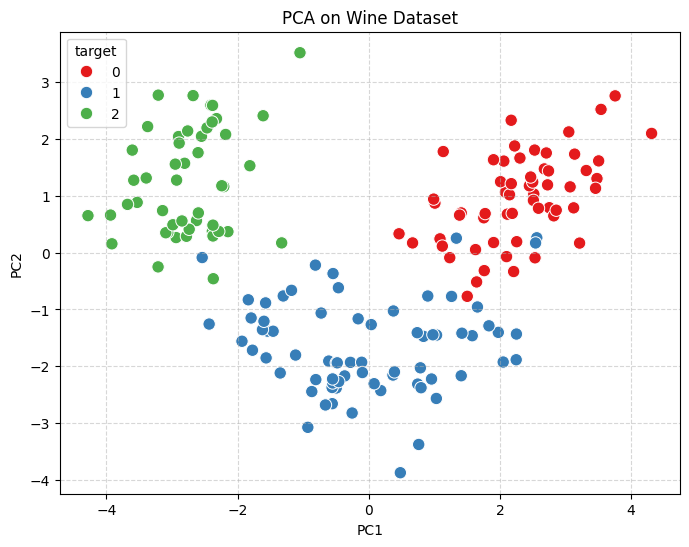


=== 분산 설명력 ===
PC1: 0.3620
PC2: 0.1921
누적: 0.5541


In [7]:
# 표준화 후 PCA 적용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y_wine

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target',
                palette='Set1', s=80)
plt.title('PCA on Wine Dataset')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"\n=== 분산 설명력 ===")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"누적: {pca.explained_variance_ratio_.sum():.4f}")

## ■ Dimensionality Reduction using PCA

■ 원본 표현
- 데이터 점: $x_i = (x_i^{(1)}, \ldots, x_i^{(d)})$

■ 변환된 표현
- **Principal components (PCs)**: 원본 feature들의 정규화된 선형 결합 $(v_1, v_2, \ldots, v_p)$
- **PC loadings**: 각 원본 변수가 그 주성분에 기여하는 정도
  - i번째 PC의 loadings = 행렬 $V$의 i번째 열 ($v_i$)
  - i번째 PC에 대한 j번째 변수의 loading = $v_{ij}$
- **PC score (Projection)**: $V^T x_i = (v_1^T x_i, \ldots, v_p^T x_i)$

■ 분산 설명력 (Explained variance)

$$\sum_{i=1}^{p} \lambda_i \,\big/\, \mathrm{trace}(C)$$


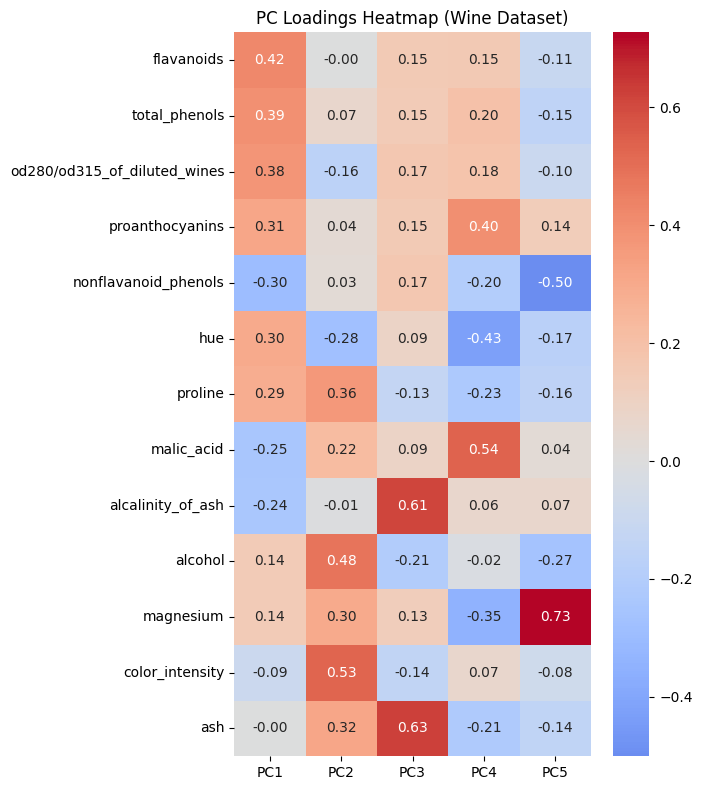

In [8]:
# 5개 PC로 다시 fit
pca5 = PCA(n_components=5)
pca5.fit(X_scaled)

loadings = pd.DataFrame(
    pca5.components_.T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=wine.feature_names
)

loadings_sorted = loadings.reindex(
    loadings['PC1'].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(7, 8))
sns.heatmap(loadings_sorted, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('PC Loadings Heatmap (Wine Dataset)')
plt.tight_layout()
plt.show()

## ■ Scree Plot

고차원 문제에서 데이터는 종종 선형 부분 공간 근처에 분포 (노이즈가 약간의 변동을 만듦).
**큰 고유값을 가진 주성분에 대한 투영만 유지** 하면 됨:
- 작은 significance 값을 갖는 component는 무시 가능
- 정보를 약간 잃을 수 있지만, 고유값이 작으면 손실도 작음

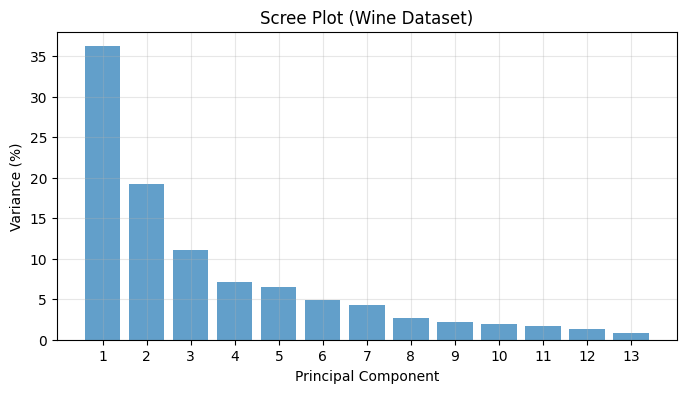

In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained)+1), explained * 100, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Variance (%)')
plt.title('Scree Plot (Wine Dataset)')
plt.xticks(range(1, len(explained)+1))
plt.grid(True, alpha=0.3)
plt.show()

## ■ PCA wrap-up

■ 강점 (Strengths)
- Eigenvector method (행렬 분해 기반의 닫힌 형태 해)
- 하이퍼파라미터 튜닝이 필요 없음 (No tuning of the parameters)
- Local optima 없음 (No local optima)

■ 약점 (Weaknesses)
- 2차 통계량(분산/공분산)만 활용 (Limited to second order statistics)
- 선형 투영에 국한 (Limited to linear projections)
  - 데이터의 구조가 비선형이면 변환된 표현이 원본 데이터 구조를 포착하지 못하고 중요한 정보를 잃을 수 있음

## ■ Eigenfaces - 얼굴 이미지에 적용한 PCA

얼굴 이미지 데이터에 PCA를 적용하면 각 주성분(PC)이 얼굴의 특징적인 패턴을 나타냄.
이를 **Eigenface** 라고 부르며, Sirovich & Kirby (1987), Turk & Pentland (1991)에서 제안.

각 원본 얼굴 이미지는 eigenface들의 선형 결합으로 표현 가능.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
=== 얼굴 데이터 크기: (400, 4096) ===
=== 이미지 한 장 크기: 64 x 64 = 4096 픽셀 ===


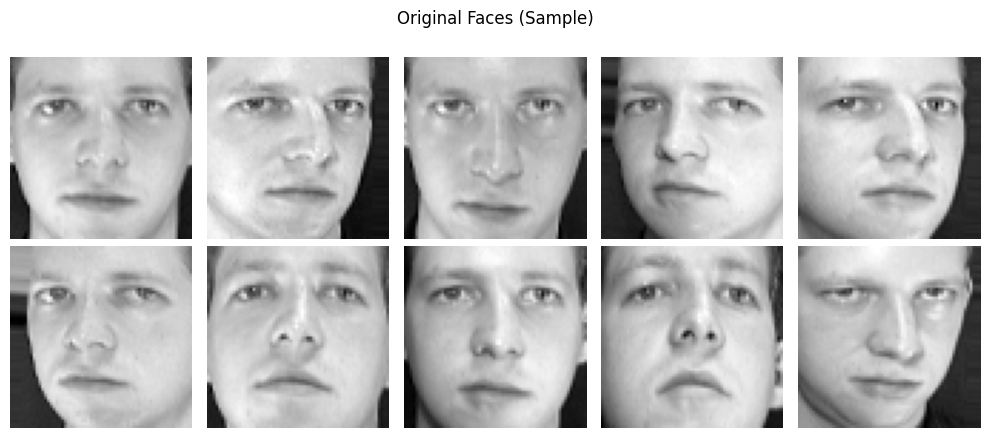

In [10]:
from sklearn.datasets import fetch_olivetti_faces

# Olivetti 얼굴 데이터셋 (40명 × 10장 = 400장, 64x64 이미지)
faces = fetch_olivetti_faces(random_state=42)
X_faces = faces.data
print(f"=== 얼굴 데이터 크기: {X_faces.shape} ===")
print(f"=== 이미지 한 장 크기: 64 x 64 = {64*64} 픽셀 ===")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Original Faces (Sample)')
plt.tight_layout()
plt.show()

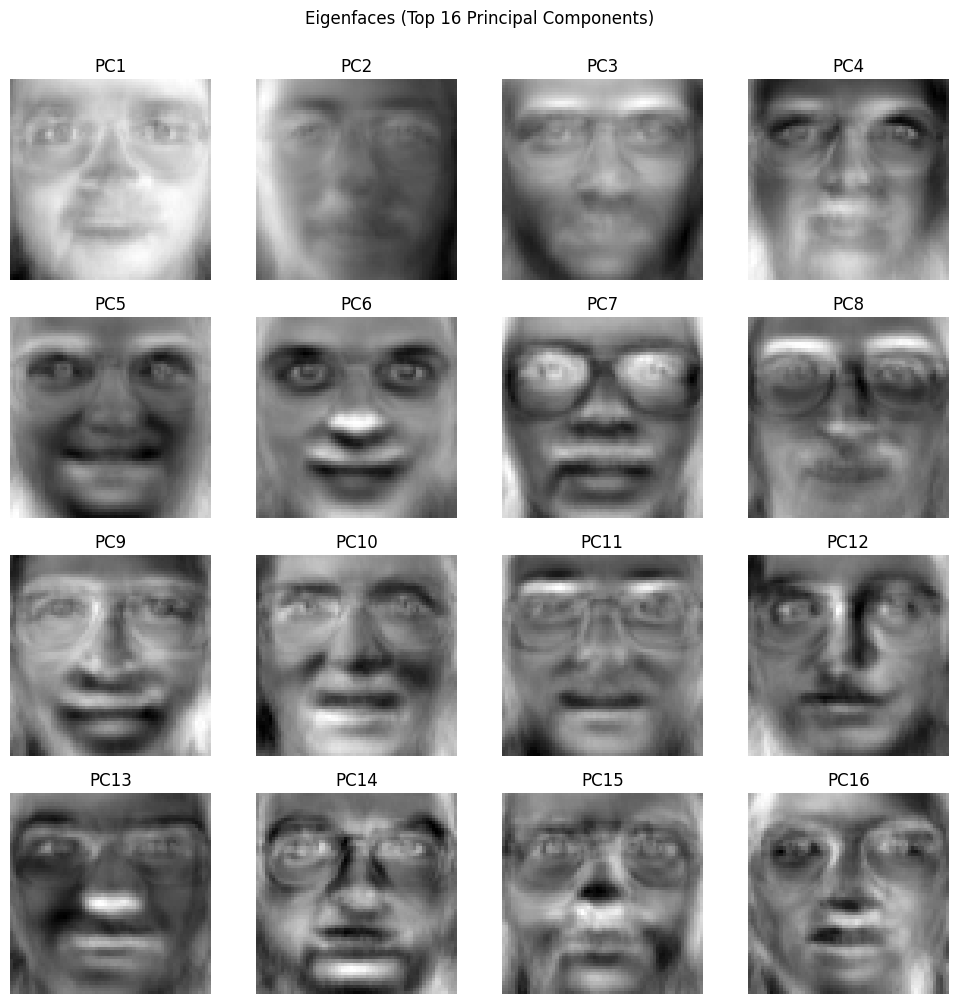


상위 16개 PC의 누적 분산 설명력: 0.7310


In [11]:
# PCA로 16개 주성분(eigenfaces) 추출
pca_faces = PCA(n_components=16)
pca_faces.fit(X_faces)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca_faces.components_[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'PC{i+1}')
    ax.axis('off')
plt.suptitle('Eigenfaces (Top 16 Principal Components)', y=1.0)
plt.tight_layout()
plt.show()

print(f"\n상위 16개 PC의 누적 분산 설명력: {pca_faces.explained_variance_ratio_.sum():.4f}")

---

## ✏️ 연습문제 1-1. Iris 데이터셋에 PCA 적용

Iris 데이터셋(`sklearn.datasets.load_iris`)에 다음 작업을 수행하시오:

1. 4개 feature를 표준화 (`StandardScaler`)
2. PCA로 2차원 축소 (`n_components=2`)
3. PC1, PC2의 개별 분산 설명력과 누적 분산 설명력 출력
4. PCA 결과를 species별로 색칠한 산점도로 시각화 (`sns.scatterplot`의 `hue` 활용)

In [12]:
# TODO: 답안을 작성하세요

# 1. Iris 데이터 불러오기
from sklearn.datasets import load_iris


# 2. 표준화


# 3. PCA 적용


# 4. 분산 설명력 출력


# 5. 시각화


## ✏️ 연습문제 1-2. Eigenfaces로 얼굴 재구성

앞서 불러온 Olivetti 얼굴 데이터 (`X_faces`)에서 100번째 얼굴(`X_faces[100]`)을
다음 K값으로 각각 재구성하시오:

- K = 5, 20, 100

요구사항:
1. 원본 얼굴과 K=5, 20, 100 재구성 결과를 가로로 4개 이미지 시각화
2. K가 커질수록 재구성 품질이 어떻게 달라지는지 관찰

**힌트**: sklearn PCA의 `inverse_transform()` 메서드 사용
- 단일 샘플은 `(1, 4096)` 형태로 reshape 필요: `target_face.reshape(1, -1)`
- 재구성: `pca_K.inverse_transform(pca_K.transform(target_face.reshape(1, -1)))`


In [13]:
# TODO: 답안을 작성하세요

target_idx = 100
target_face = X_faces[target_idx]

K_values = [5, 20, 100]

# 1x4 subplot 생성


# 원본 얼굴 표시 (axes[0])


# K=5, 20, 100 각각에 대해 PCA 학습 → 재구성 → 표시


# Part 2. PCA vs LDA

|  | PCA | LDA |
|---|---|---|
| **Objective** | 데이터의 분산 최대화 | 클래스 간 분리 최대화 |
| **Data Requirements** | feature 행렬만 | feature 행렬 + 클래스 라벨 |
| **Number of Components** | 최대 d (feature 수) | 최대 C-1 (클래스 수 - 1) |
| **Usage** | 차원 축소, 시각화, 노이즈 제거, feature 추출 | 분류 + 분류용 차원 축소 |
| **Optimization Criteria** | 전체 분산 최대화 | 클래스 간 분산 / 클래스 내 분산 비율 최대화 |

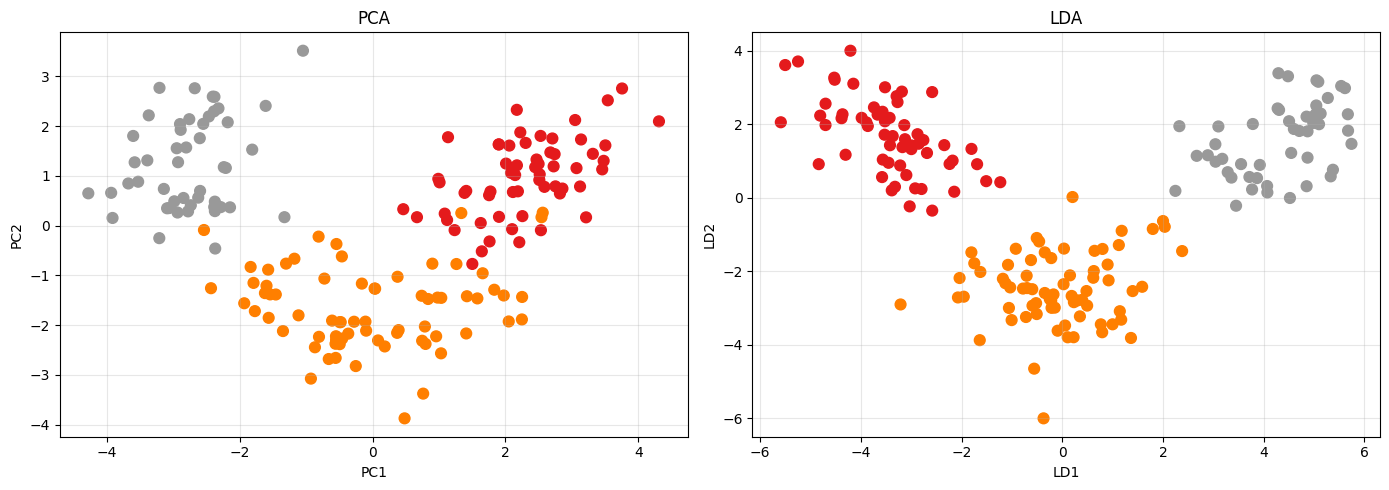

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_wine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_wine, cmap='Set1', s=60)
axes[0].set_title('PCA')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y_wine, cmap='Set1', s=60)
axes[1].set_title('LDA')
axes[1].set_xlabel('LD1'); axes[1].set_ylabel('LD2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## ✏️ 연습문제 2. Digits 데이터에 PCA vs LDA

손글씨 숫자 데이터셋(`sklearn.datasets.load_digits`, 10개 클래스)에
PCA와 LDA를 각각 적용하여 2차원으로 축소하고 결과를 비교하시오.

요구사항:
1. 표준화 후 PCA 2차원 축소
2. 표준화 후 LDA 2차원 축소
3. 두 결과를 1×2 subplot으로 시각화 (각 클래스를 색깔로 구분, `cmap='tab10'`)
4. 어느 쪽이 클래스를 더 잘 분리하는지 관찰

In [15]:
# TODO: 답안을 작성하세요

from sklearn.datasets import load_digits

# 1. Digits 데이터 불러오기


# 2. 표준화


# 3. PCA 2차원 축소


# 4. LDA 2차원 축소 (라벨 필요!)


# 5. 시각화


# Part 3. Manifold Learning - 비선형 차원 축소

PCA는 **선형(linear)** 투영이라 데이터 구조가 비선형이면 정보를 잃는다.

■ Manifold 가정 (Manifold hypothesis)
- 고차원 데이터는 사실 저차원 manifold(다양체) 위에 분포함
- **국소적으로(locally)** 는 유클리드 공간처럼 보이지만, 전역적으로는 휘어진 구조
- Manifold = 고차원 공간의 부분집합 중 국소적으로 저차원 공간처럼 보이는 구조

■ 대표 예시: Swiss Roll
- 3차원 공간에 말려있는 종이 모양
- 사실은 2차원 평면 위의 데이터를 휘어놓은 것
- PCA로는 펼 수 없지만, manifold learning으로는 가능

■ 핵심 아이디어: 측지 거리(Geodesic distance)
- 직선거리(유클리드)는 manifold 구조를 무시
- **manifold를 따라가는 거리** 를 사용하면 manifold 구조 보존 가능
- 가까운 점들끼리만 그래프로 연결한 뒤, 그래프 위 최단 경로로 측지 거리를 근사
- "Unfolding"된 manifold 위에서는 클러스터링 등의 분석이 쉬워짐

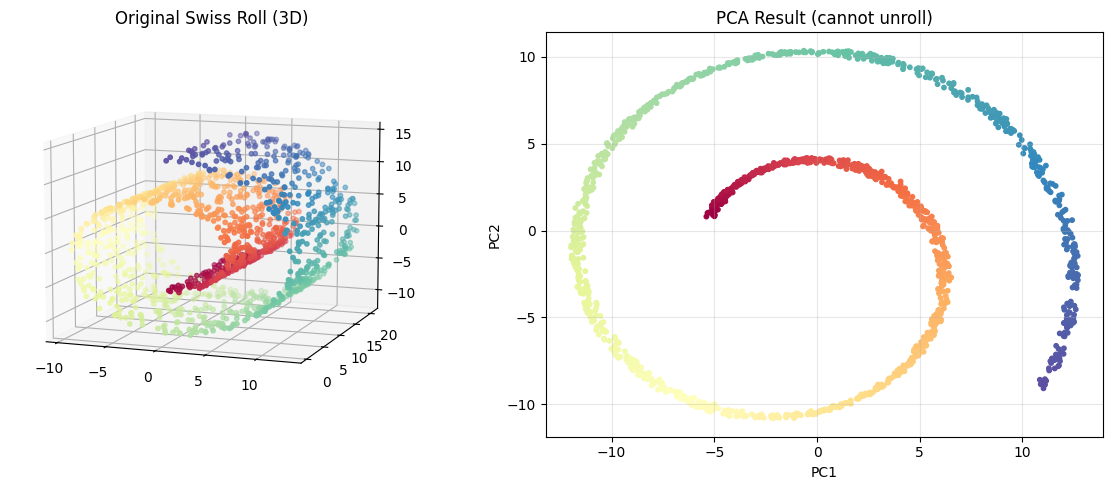

In [16]:
from sklearn.datasets import make_swiss_roll

X_swiss, color = make_swiss_roll(n_samples=1500, noise=0.05, random_state=42)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2],
            c=color, cmap='Spectral', s=10)
ax1.set_title('Original Swiss Roll (3D)')
ax1.view_init(10, -70)

pca_swiss = PCA(n_components=2)
X_swiss_pca = pca_swiss.fit_transform(X_swiss)

ax2 = fig.add_subplot(122)
ax2.scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1],
            c=color, cmap='Spectral', s=10)
ax2.set_title('PCA Result (cannot unroll)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ■ Similarity Graph - 데이터 기하 모델링

■ 그래프 정의
- $G = (V, E)$: vertices 집합 $V$, edges 집합 $E \subset V \times V$
- 그래프는 객체 간의 pairwise relation (similarity 또는 distance)을 모델링
- **가중치 그래프(Weighted graph)**: 각 edge에 weight $w_{ij}$ 부여 (관계의 강도)

■ 우리가 다루는 그래프
- Weighted **undirected** graph
- 가중치는 비음수: $w_{ij} \ge 0$
- $w_{ij} = 0$ ⟺ 정점 $i, j$가 연결되지 않음

■ Vertex의 Degree

$$\deg(i) = \sum_{j=1}^n w_{ij}$$

■ 가중 인접 행렬 (Weighted adjacency matrix)
- 가중 무방향 그래프는 $w_{ij}$를 원소로 하는 행렬 $W$로 표현 가능

■ 그래프 구성 방법 두 가지

원본 데이터 공간의 유클리드 거리 $d(x_i, x_j)$가 주어졌을 때,

- **Option 1: ε-ball graph**: $d(x_i, x_j) \le \epsilon$이면 $i, j$를 연결
- **Option 2: k-NN graph**: $i$가 $j$의 k개 최근접 이웃이거나 (또는 그 반대) 연결

In [17]:
from scipy.spatial.distance import cdist

# 5개 정점으로 이루어진 작은 그래프
points_g = np.array([
    [0, 0],
    [1, 0],
    [0.5, 0.866],
    [2, 0.5],
    [3, 0]
])
n_v = points_g.shape[0]

D_g = cdist(points_g, points_g)
print("--- 거리 행렬 D ---")
display(pd.DataFrame(D_g.round(2),
                     index=[f'v{i}' for i in range(n_v)],
                     columns=[f'v{i}' for i in range(n_v)]))

# 가중 인접 행렬 W (ε-ball graph, ε=1.5)
epsilon = 1.5
W = np.where((D_g > 0) & (D_g <= epsilon), 1.0, 0.0)
print(f"\n--- 가중 인접 행렬 W (ε={epsilon}, 연결: 1, 미연결: 0) ---")
display(pd.DataFrame(W,
                     index=[f'v{i}' for i in range(n_v)],
                     columns=[f'v{i}' for i in range(n_v)]))

degrees = W.sum(axis=1)
print("\n--- 각 정점의 Degree ---")
for i, d in enumerate(degrees):
    print(f"deg(v{i}) = {d:.0f}")

--- 거리 행렬 D ---


,v0,v1,v2,v3,v4
v0,0.00,1.00,1.00,2.06,3.00
v1,1.00,0.00,1.00,1.12,2.00
v2,1.00,1.00,0.00,1.54,2.65
v3,2.06,1.12,1.54,0.00,1.12
v4,3.00,2.00,2.65,1.12,0.00



--- 가중 인접 행렬 W (ε=1.5, 연결: 1, 미연결: 0) ---


,v0,v1,v2,v3,v4
v0,0.0,1.0,1.0,0.0,0.0
v1,1.0,0.0,1.0,1.0,0.0
v2,1.0,1.0,0.0,0.0,0.0
v3,0.0,1.0,0.0,0.0,1.0
v4,0.0,0.0,0.0,1.0,0.0



--- 각 정점의 Degree ---
deg(v0) = 2
deg(v1) = 3
deg(v2) = 2
deg(v3) = 2
deg(v4) = 1


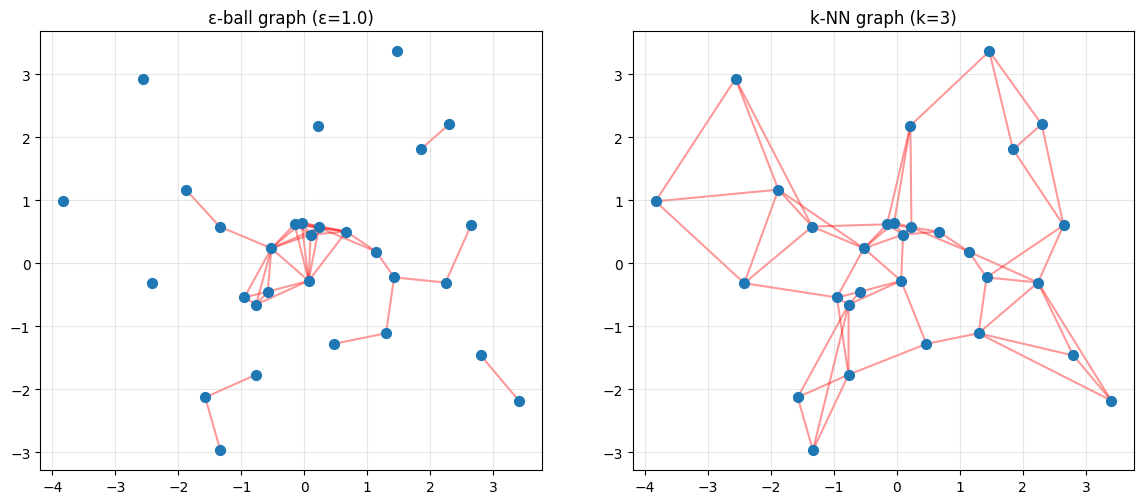

In [18]:
from sklearn.neighbors import NearestNeighbors

np.random.seed(0)
X_demo = np.random.randn(30, 2) * 1.5

# 1. ε-ball graph
epsilon_demo = 1.0
D_demo = cdist(X_demo, X_demo)
W_eps = (D_demo <= epsilon_demo) & (D_demo > 0)

# 2. k-NN graph (k=3)
k = 3
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_demo)
_, indices = nbrs.kneighbors(X_demo)
W_knn = np.zeros((len(X_demo), len(X_demo)), dtype=bool)
for i, neigh in enumerate(indices):
    for j in neigh[1:]:
        W_knn[i, j] = True
        W_knn[j, i] = True

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, W_g, title in zip(
    axes, [W_eps, W_knn],
    [f'ε-ball graph (ε={epsilon_demo})', f'k-NN graph (k={k})']
):
    ax.scatter(X_demo[:, 0], X_demo[:, 1], s=50, zorder=2, c='C0')
    for i in range(len(X_demo)):
        for j in range(i+1, len(X_demo)):
            if W_g[i, j]:
                ax.plot([X_demo[i, 0], X_demo[j, 0]],
                        [X_demo[i, 1], X_demo[j, 1]],
                        'r-', alpha=0.4, zorder=1)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## ✏️ 연습문제 3. Iris setosa의 k-NN graph 분석

Iris 데이터에서 setosa 종(첫 50개 샘플)에 대해 다음을 수행하시오:

1. 4차원 feature 공간에서 **k=5**인 k-NN graph 구성 (무방향)
2. 인접 행렬 W의 다음 통계 출력:
   - 총 edge 수 (대칭이므로 W.sum() // 2)
   - 각 정점의 degree 분포: 평균, 최대, 최소

**참고**: setosa 추출은 `iris.data[iris.target == 0]` 으로 가능

In [19]:
# TODO: 답안을 작성하세요

# 1. setosa 50개 샘플 추출


# 2. k=5 k-NN graph 구성 (NearestNeighbors 사용)


# 3. 인접 행렬을 무방향으로 (i↔j 양쪽 모두 1)


# 4. 통계 출력


# Part 4. Multi-Dimensional Scaling (MDS)

MDS는 **점들 사이의 거리(distance)를 최대한 보존** 하면서 저차원에 임베딩하는 기법

■ 핵심 아이디어
- 원본 데이터 점 $x_1, \ldots, x_n \in \mathbb{R}^d$가 주어졌을 때
- 저차원 표현 $y_1, \ldots, y_n \in \mathbb{R}^p$를 찾되, $\|y_i - y_j\| \approx d(x_i, x_j)$ 가 되도록

■ Translational invariance (해의 비유일성)
- 어떤 평행이동을 해도 점 사이의 거리는 보존됨 → 해는 유일하지 않음
- 제약 추가: $\sum y_i = 0$ (임베딩의 중심을 원점으로)

■ MDS 문제

$$\|y_i - y_j\|_2 \approx d(x_i, x_j) = \ell_{ij}, \quad \forall i, j$$

다양한 거리 사용 가능: $\ell_p$, cosine distance, geodesic distance

## ■ MDS 유도 (Classic MDS)

가정: $\|y_i - y_j\|_2 = \ell_{ij}$. 양변을 제곱:

$$\ell_{ij}^2 = \|y_i\|^2 + \|y_j\|^2 - 2\, y_i^T y_j$$

$i$ 대해 합산하면 $\sum_i \ell_{ij}^2 = \sum_i \|y_i\|^2 + n\|y_j\|^2$

$j$ 대해 합산하면 $\sum_j \ell_{ij}^2 = \sum_j \|y_j\|^2 + n\|y_i\|^2$

표기 정의:

$$\ell_{\cdot j}^2 = \sum_i \ell_{ij}^2, \quad \ell_{i\cdot}^2 = \sum_j \ell_{ij}^2, \quad \ell_{\cdot\cdot}^2 = \sum_i\sum_j \ell_{ij}^2$$

위 두 식을 모두 더하면:

$$\ell_{\cdot\cdot}^2 = 2n \sum_k \|y_k\|^2 \implies \sum_k \|y_k\|^2 = \frac{1}{2n} \ell_{\cdot\cdot}^2$$

대입:

$$\|y_j\|^2 = \frac{1}{n}\ell_{\cdot j}^2 - \frac{1}{2n^2}\ell_{\cdot\cdot}^2, \quad \|y_i\|^2 = \frac{1}{n}\ell_{i\cdot}^2 - \frac{1}{2n^2}\ell_{\cdot\cdot}^2$$

최종적으로:

$$y_i^T y_j = \frac{1}{2}\left[\frac{1}{n}\ell_{i\cdot}^2 + \frac{1}{n}\ell_{\cdot j}^2 - \frac{1}{n^2}\ell_{\cdot\cdot}^2 - \ell_{ij}^2\right] := g_{ij}$$

■ 행렬 표현
- Gram 행렬 (대칭): $G = [g_{ij}] \in \mathbb{R}^{n \times n}$
- 임베딩 행렬: $Y = [y_1, \ldots, y_n]^T \in \mathbb{R}^{n \times k}$
- 문제: $YY^T \approx G$
- 동치 표현: $G = -\frac{1}{2} J L J$, 단 $L = [\ell_{ij}^2], \; J = I_n - \frac{1}{n} \mathbf{1}\mathbf{1}^T$
- $G$의 모든 행/열 합이 0 → $G$는 고유값 0을 가짐

■ 해의 유일성
- $G$가 양의 준정부호(positive semi-definite)이면 $G = V \Lambda V^T$
- 상위 $p$개 고유값/고유벡터로 근사: $G \approx V_p \Lambda_p V_p^T = YY^T$ → $\boxed{Y = V_p \Lambda_p^{1/2}}$


## ■ Toy example (수작업: Gram 행렬 → 고유값 분해)

In [20]:
# 정사각형 4개 꼭짓점
points = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
])

n = points.shape[0]

# 1. 거리 행렬 D
D = cdist(points, points, metric='euclidean')
print("--- 거리 행렬 D ---")
display(pd.DataFrame(D))

# 2. 거리 제곱 행렬 L
L = D ** 2

# 3. 중심화 행렬 J = I - (1/n) * 1*1^T
J = np.eye(n) - np.ones((n, n)) / n

# 4. Gram 행렬 G = -0.5 * J * L * J
G = -0.5 * J @ L @ J
print("\n--- Gram 행렬 G ---")
display(pd.DataFrame(G))

# 5. 고유값 분해
eigvals, eigvecs = np.linalg.eigh(G)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
print(f"\n--- 고유값 (Gram 행렬) ---\n{eigvals}")
print("→ 마지막 고유값은 0 (G의 행/열 합이 모두 0)")

# 6. 임베딩
p = 2
Y = eigvecs[:, :p] * np.sqrt(np.maximum(eigvals[:p], 0))
print(f"\n--- 2D 임베딩 결과 ---")
display(pd.DataFrame(Y, columns=['Y1', 'Y2']))

--- 거리 행렬 D ---


,0,1,2,3
0,0.000000,1.000000,1.414214,1.000000
1,1.000000,0.000000,1.000000,1.414214
2,1.414214,1.000000,0.000000,1.000000
3,1.000000,1.414214,1.000000,0.000000



--- Gram 행렬 G ---


,0,1,2,3
0,5.000000e-01,8.326673e-17,-5.000000e-01,9.714451e-17
1,8.326673e-17,5.000000e-01,9.714451e-17,-5.000000e-01
2,-5.000000e-01,9.714451e-17,5.000000e-01,9.714451e-17
3,1.110223e-16,-5.000000e-01,1.110223e-16,5.000000e-01



--- 고유값 (Gram 행렬) ---
[ 1.00000000e+00  1.00000000e+00  3.05591459e-18 -3.36122822e-16]
→ 마지막 고유값은 0 (G의 행/열 합이 모두 0)

--- 2D 임베딩 결과 ---


,Y1,Y2
0,0.000000,-7.071068e-01
1,-0.707107,0.000000e+00
2,0.000000,7.071068e-01
3,0.707107,-2.826460e-17


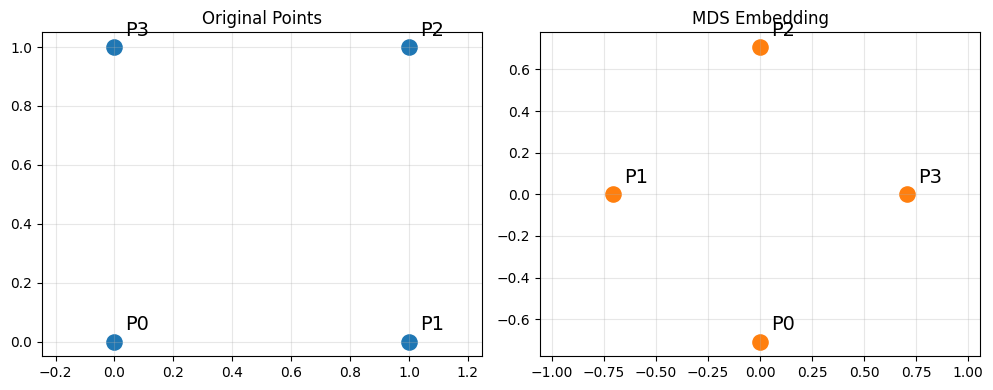

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(points[:, 0], points[:, 1], s=120, color='C0')
for i, (x, y) in enumerate(points):
    axes[0].annotate(f'P{i}', (x, y), fontsize=14,
                     xytext=(8, 8), textcoords='offset points')
axes[0].set_title('Original Points')
axes[0].axis('equal'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(Y[:, 0], Y[:, 1], s=120, color='C1')
for i, (x, y) in enumerate(Y):
    axes[1].annotate(f'P{i}', (x, y), fontsize=14,
                     xytext=(8, 8), textcoords='offset points')
axes[1].set_title('MDS Embedding')
axes[1].axis('equal'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ■ Sklearn MDS

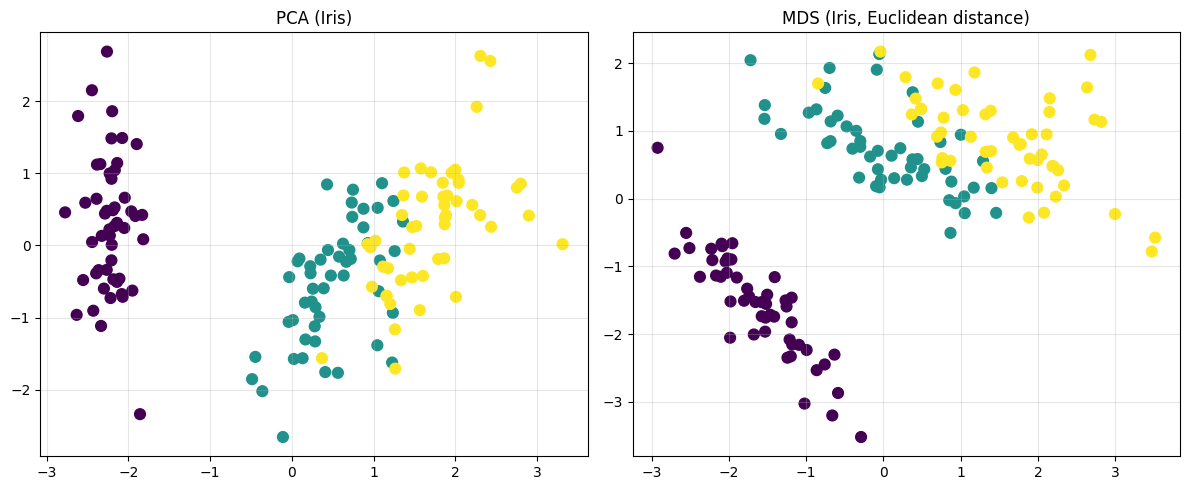

In [22]:
from sklearn.manifold import MDS
from sklearn.datasets import load_iris

iris = load_iris()
X_iris_for_mds = StandardScaler().fit_transform(iris.data)

mds = MDS(n_components=2, random_state=42, n_init=4, normalized_stress='auto')
X_mds = mds.fit_transform(X_iris_for_mds)

pca_iris_compare = PCA(n_components=2)
X_pca_iris_compare = pca_iris_compare.fit_transform(X_iris_for_mds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca_iris_compare[:, 0], X_pca_iris_compare[:, 1],
                c=iris.target, cmap='viridis', s=60)
axes[0].set_title('PCA (Iris)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_mds[:, 0], X_mds[:, 1],
                c=iris.target, cmap='viridis', s=60)
axes[1].set_title('MDS (Iris, Euclidean distance)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## ✏️ 연습문제 4. 도시 거리 행렬에서 좌표 복원

한국의 주요 도시 5개의 직선 거리(km)가 아래와 같이 주어졌을 때,
MDS로 2차원 좌표를 복원하시오.

|        | 서울 | 부산 | 대구 | 광주 | 대전 |
|--------|------|------|------|------|------|
| **서울** |  0   | 325  | 237  | 267  | 140  |
| **부산** | 325  |  0   |  88  | 228  | 200  |
| **대구** | 237  |  88  |  0   | 178  | 105  |
| **광주** | 267  | 228  | 178  |  0   | 140  |
| **대전** | 140  | 200  | 105  | 140  |  0   |

요구사항:
1. 위 거리 행렬을 numpy array로 만들기
2. sklearn MDS 적용 (`dissimilarity='precomputed'` 옵션 사용)
3. 결과 좌표를 산점도로 시각화 (각 도시명을 라벨로 표시)

**참고**: MDS는 회전/반전 무관 → 결과가 실제 지도와 회전·반전된 형태일 수 있지만 상대적 위치는 보존됨

In [23]:
# TODO: 답안을 작성하세요

# 1. 거리 행렬 정의
cities = ['Seoul', 'Busan', 'Daegu', 'Gwangju', 'Daejeon']
# D_cities = np.array([...])


# 2. MDS 적용 (dissimilarity='precomputed')


# 3. 시각화 (도시명 라벨 포함)


# Part 5. Isomap

**Isomap = k-NN 그래프 + Dijkstra(측지 거리) + MDS**

■ 알고리즘

주어진 $n$개의 데이터 점 $x_1, \ldots, x_n \in \mathbb{R}^d$에 대해:

1. **k-최근접 이웃 그래프 $G = (V, E)$ 구성**
2. **Dijkstra 알고리즘으로 그래프 위 최단 경로 거리** $d_G(x_i, x_j)$ 계산 (모든 점 쌍)
3. **측지 거리 행렬에 metric MDS 적용** 하여 저차원 임베딩

## ■ Dijkstra 알고리즘 - 단계별 동작

작은 그래프에서 시작 정점 v1로부터 모든 다른 정점까지의 최단 경로 거리를 계산해보자.

/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1323/3547446015.py:59: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_l

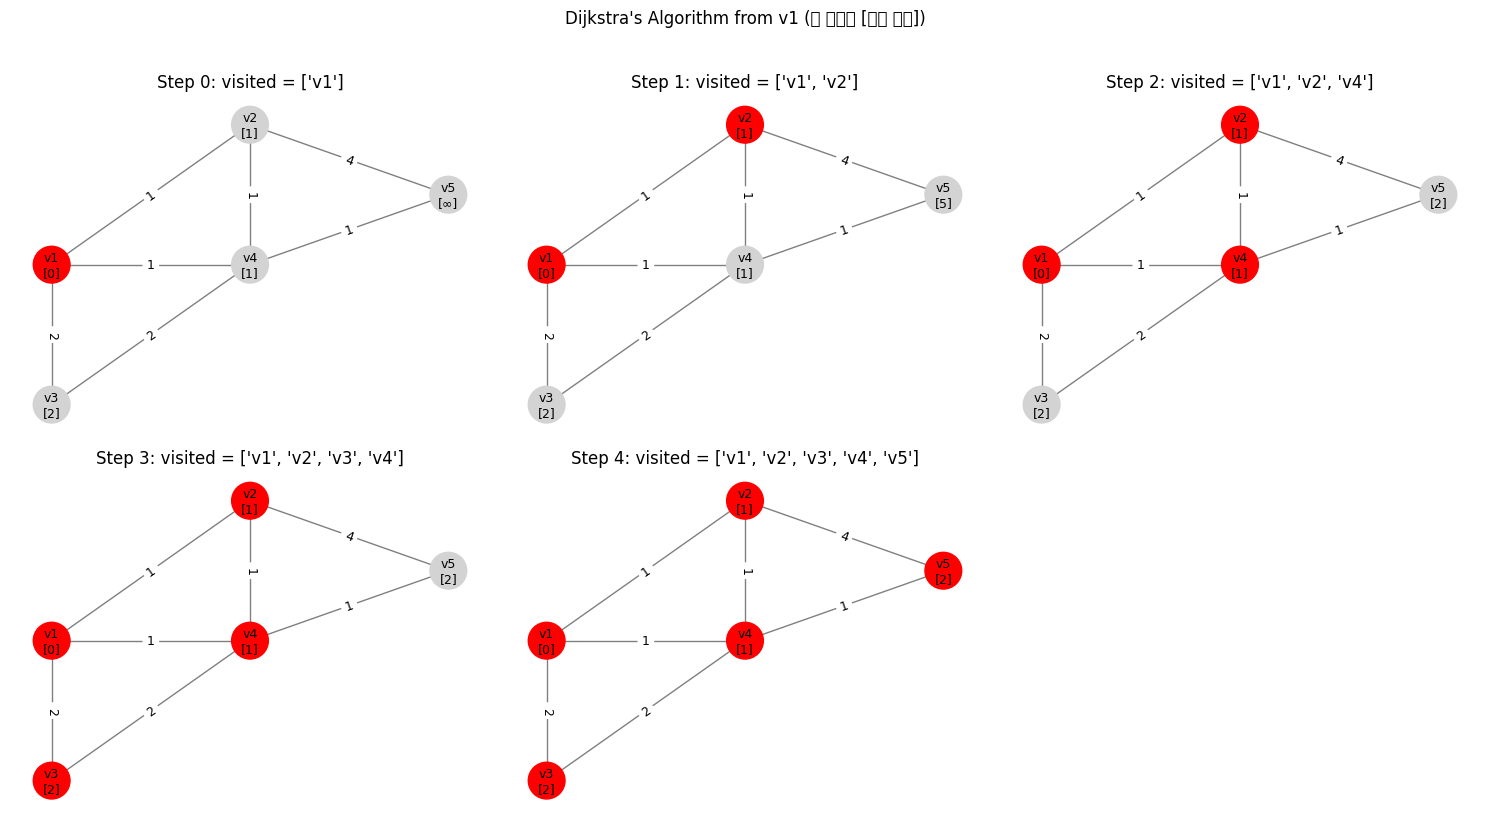


=== v1으로부터의 최단 거리 (geodesic distance) ===
  d_G(v1, v1) = 0
  d_G(v1, v2) = 1
  d_G(v1, v3) = 2
  d_G(v1, v4) = 1
  d_G(v1, v5) = 2


In [24]:
import networkx as nx

G_demo = nx.Graph()
edges = [
    ('v1', 'v2', 1),
    ('v1', 'v3', 2),
    ('v1', 'v4', 1),
    ('v2', 'v4', 1),
    ('v2', 'v5', 4),
    ('v3', 'v4', 2),
    ('v4', 'v5', 1),
]
G_demo.add_weighted_edges_from(edges)

pos = {
    'v1': (0, 0),
    'v2': (1, 1),
    'v3': (0, -1),
    'v4': (1, 0),
    'v5': (2, 0.5),
}

def dijkstra_steps(G, source):
    distances = {node: float('inf') for node in G.nodes()}
    distances[source] = 0
    visited = set()
    steps = []
    while len(visited) < len(G.nodes()):
        unvisited = {n: distances[n] for n in G.nodes() if n not in visited}
        current = min(unvisited, key=unvisited.get)
        visited.add(current)
        for neighbor in G.neighbors(current):
            new_dist = distances[current] + G[current][neighbor]['weight']
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
        steps.append((set(visited), dict(distances)))
    return steps

steps = dijkstra_steps(G_demo, 'v1')
edge_labels = {(u, v): d['weight'] for u, v, d in G_demo.edges(data=True)}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for step_idx, ax in enumerate(axes.flat):
    if step_idx >= len(steps):
        ax.axis('off')
        continue
    visited, dists = steps[step_idx]
    node_colors = ['red' if n in visited else 'lightgray' for n in G_demo.nodes()]
    nx.draw_networkx_nodes(G_demo, pos, ax=ax, node_color=node_colors, node_size=700)
    nx.draw_networkx_edges(G_demo, pos, ax=ax, alpha=0.5)
    nx.draw_networkx_edge_labels(G_demo, pos, edge_labels=edge_labels, ax=ax, font_size=9)
    labels = {n: f'{n}\n[{dists[n] if dists[n] != float("inf") else "∞"}]'
              for n in G_demo.nodes()}
    nx.draw_networkx_labels(G_demo, pos, labels=labels, ax=ax, font_size=9)
    ax.set_title(f'Step {step_idx}: visited = {sorted(visited)}')
    ax.axis('off')

plt.suptitle("Dijkstra's Algorithm from v1 (각 노드의 [현재 거리])", y=1.02)
plt.tight_layout()
plt.show()

print("\n=== v1으로부터의 최단 거리 (geodesic distance) ===")
final_dists = nx.single_source_dijkstra_path_length(G_demo, 'v1')
for node in sorted(final_dists):
    print(f"  d_G(v1, {node}) = {final_dists[node]}")

## ■ Isomap on Swiss Roll - PCA, MDS와 비교

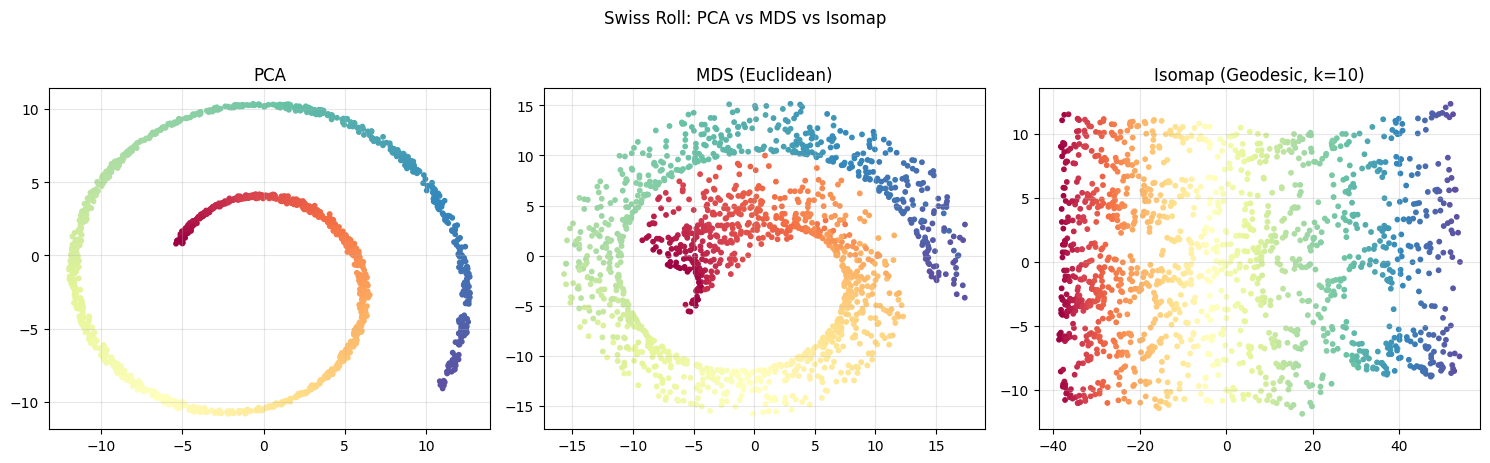

In [25]:
from sklearn.manifold import Isomap

isomap = Isomap(n_neighbors=10, n_components=2)
X_swiss_iso = isomap.fit_transform(X_swiss)

mds_swiss = MDS(n_components=2, random_state=42, n_init=2, normalized_stress='auto')
X_swiss_mds = mds_swiss.fit_transform(X_swiss)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1],
                c=color, cmap='Spectral', s=10)
axes[0].set_title('PCA'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_swiss_mds[:, 0], X_swiss_mds[:, 1],
                c=color, cmap='Spectral', s=10)
axes[1].set_title('MDS (Euclidean)'); axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_swiss_iso[:, 0], X_swiss_iso[:, 1],
                c=color, cmap='Spectral', s=10)
axes[2].set_title('Isomap (Geodesic, k=10)'); axes[2].grid(True, alpha=0.3)

plt.suptitle('Swiss Roll: PCA vs MDS vs Isomap', y=1.02)
plt.tight_layout()
plt.show()

---

## ✏️ 연습문제 5. Swiss Roll에서 n_neighbors 영향 관찰

Swiss Roll 데이터(`X_swiss`, `color`는 이미 정의됨)에 Isomap을 적용할 때,
`n_neighbors`를 다음 값으로 바꿔가며 결과를 시각화하시오:

- n_neighbors = 5, 10, 30, 100

요구사항:
1. 1×4 subplot으로 각 n_neighbors 값에 대한 Isomap 결과 시각화
2. `c=color`, `cmap='Spectral'`로 manifold 위 위치를 색칠
3. n_neighbors가 너무 작거나 너무 클 때 어떤 문제가 생기는지 결과로 확인

In [26]:
# TODO: 답안을 작성하세요

neighbors_list = [5, 10, 30, 100]

# 1x4 subplot 생성


# 각 n_neighbors 값에 대해 Isomap 적용 후 시각화


# Part 6. t-SNE

t-SNE는 SNE (2002) → Symmetric SNE → t-SNE (2008) 의 단계를 거쳐 발전한 기법.
각 단계에서 어떤 문제를 해결하기 위해 무엇이 바뀌었는지 살펴보자.

## ■ Step 1: SNE (Stochastic Neighbor Embedding)

**아이디어**: 유클리드 거리를 **조건부 확률** 로 바꿔서 표현하자.

고차원 공간에서 점 $x_i$가 점 $x_j$를 이웃으로 선택할 확률 (가우시안 기반):

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

(자기 자신은 $p_{i|i} = 0$)

저차원 임베딩 $y_i$에서도 동일하게:

$$q_{j|i} = \frac{\exp(-\|y_i - y_j\|^2)}{\sum_{k \neq i} \exp(-\|y_i - y_k\|^2)}$$

**비용 함수**: 두 분포의 KL divergence

$$C = \sum_i KL(P_i \| Q_i) = \sum_{i,j} p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$$

**Gradient**:

$$\frac{\partial C}{\partial y_i} = 2 \sum_j (p_{j|i} - q_{j|i} + p_{i|j} - q_{i|j})(y_i - y_j)$$

**특징**
- 가까운 점은 $p_{j|i}$가 비교적 큼, 멀리 떨어진 점은 거의 0
- 데이터의 **국소 구조 보존** 에 집중
- 적절한 $\sigma_i$를 찾기 위해 데이터셋마다 여러 번 최적화 필요

## ■ Step 2: Symmetric SNE

**문제점**: SNE는 conditional probability라 $p_{j|i} \ne p_{i|j}$.
**outlier가 있으면 그 점의 위치에 따라 저차원 임베딩이 좌우됨**!

**해결책**: 대칭화된 결합 확률(joint probability) 사용

$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

$$q_{ij} = \frac{\exp(-\|y_i - y_j\|^2)}{\sum_{k \neq l} \exp(-\|y_k - y_l\|^2)}$$

**비용 함수**:

$$C = KL(P \| Q) = \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**Gradient** (더 간단해짐):

$$\frac{\partial C}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij})(y_i - y_j)$$

## ■ Step 3: t-SNE

**문제점: Crowding problem**

2차원 평면이 *moderately distant* 한 점들을 수용할 공간이, 가까운 점들의 영역에 비해
충분히 크지 않음. 결과적으로 점들이 한 곳에 몰리는 현상이 생김.

**해결책**: 저차원 $q_{ij}$에 가우시안 대신 **꼬리가 두꺼운 Student's t-분포** (자유도 1, Cauchy 분포) 사용

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

**Gradient**:

$$\frac{\partial C}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij})(y_i - y_j)\,(1 + \|y_i - y_j\|^2)^{-1}$$

**효과**
- 고차원 공간의 중간 거리를 저차원에서 훨씬 큰 거리로 표현 가능
- 적당히 떨어진 점들 간의 불필요한 인력(attractive force) 제거
- 클러스터가 명확히 분리되어 시각화에 적합

## ■ t-SNE 알고리즘 (의사코드)

```
Algorithm 1: Simple version of t-Distributed Stochastic Neighbor Embedding

Data:    data set X = {x1, x2, ..., xn}
Cost:    perplexity Perp
Optim:   number of iterations T, learning rate η, momentum α(t)
Result:  low-dimensional data representation Y(T) = {y1, y2, ..., yn}

begin
    compute pairwise affinities p_{j|i} with perplexity Perp
    set p_{ij} = (p_{j|i} + p_{i|j}) / 2n
    sample initial solution Y(0) = {y1, ..., yn} from N(0, 10⁻⁴ I)

    for t = 1 to T do
        compute low-dimensional affinities q_{ij}
        compute gradient ∂C/∂Y
        set Y(t) = Y(t-1) + η · ∂C/∂Y + α(t) · (Y(t-1) - Y(t-2))
    end
end
```

> Maaten, L. V. D., & Hinton, G. (2008). Visualizing data using t-SNE.
> Journal of Machine Learning Research, 9, 2579-2605.

t-SNE는 **시각화 전용** - 새 데이터 변환 불가, `fit_transform()`만 사용 가능.

=== Digits 데이터 크기: (1797, 64) ===
=== 클래스 수: 10 ===


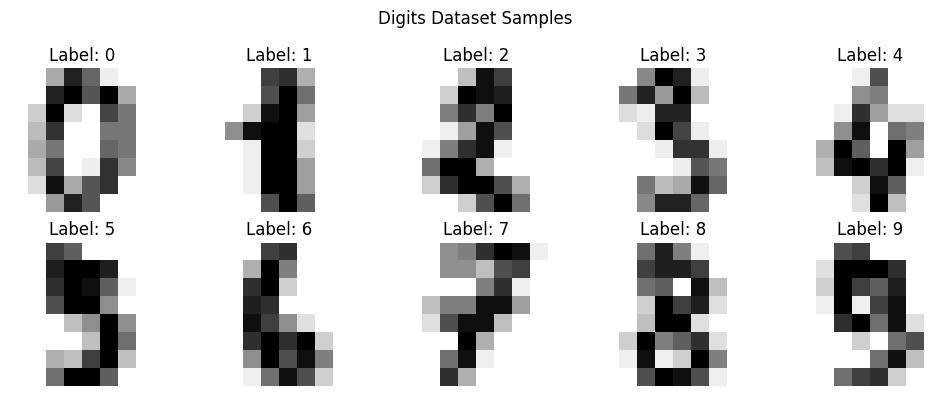

In [27]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"=== Digits 데이터 크기: {X_digits.shape} ===")
print(f"=== 클래스 수: {len(np.unique(y_digits))} ===")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Label: {y_digits[i]}')
    ax.axis('off')
plt.suptitle('Digits Dataset Samples')
plt.tight_layout()
plt.show()

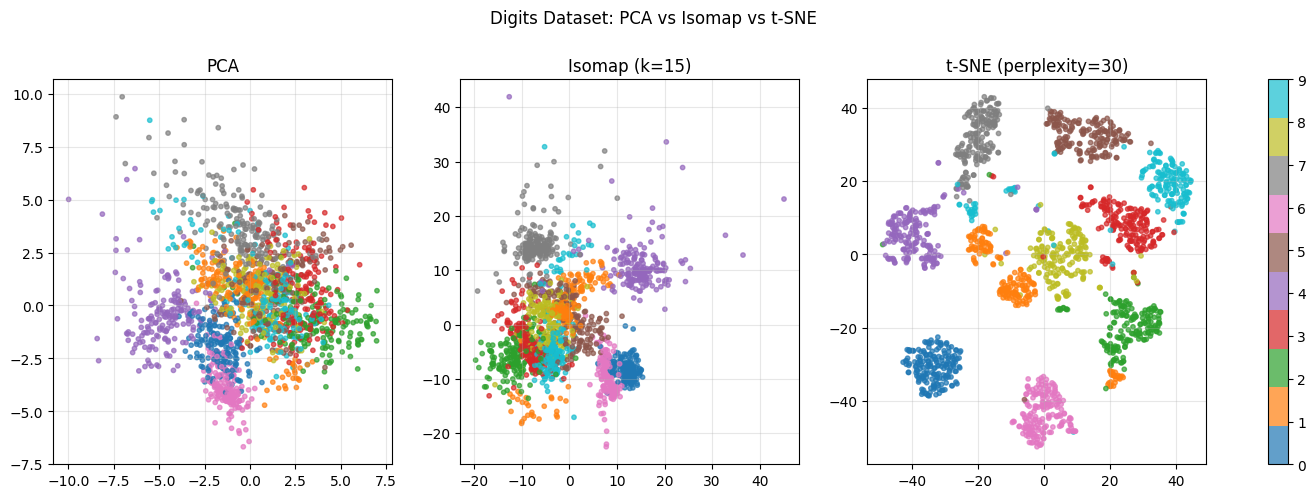

In [28]:
X_digits_scaled = StandardScaler().fit_transform(X_digits)

pca_d = PCA(n_components=2)
X_pca_d = pca_d.fit_transform(X_digits_scaled)

iso_d = Isomap(n_neighbors=15, n_components=2)
X_iso_d = iso_d.fit_transform(X_digits_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_digits_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, X_emb, title in zip(
    axes,
    [X_pca_d, X_iso_d, X_tsne],
    ['PCA', 'Isomap (k=15)', 't-SNE (perplexity=30)']
):
    sc = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_digits,
                    cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.colorbar(sc, ax=axes, fraction=0.02)
plt.suptitle('Digits Dataset: PCA vs Isomap vs t-SNE', y=1.02)
plt.show()

---

## ✏️ 연습문제 6. Digits 데이터에서 perplexity 영향 관찰

Digits 데이터(`X_digits_scaled`, `y_digits`는 이미 정의됨)에 t-SNE를 적용할 때,
`perplexity`를 다음 값으로 바꿔가며 결과를 시각화하시오:

- perplexity = 5, 30, 100

요구사항:
1. 1×3 subplot으로 각 perplexity 값에 대한 t-SNE 결과 시각화
2. `c=y_digits`, `cmap='tab10'`로 클래스별 색칠
3. perplexity가 너무 작거나 너무 클 때 결과가 어떻게 달라지는지 관찰

**힌트**: `random_state=42`, `init='pca'`로 고정해두면 perplexity 영향만 볼 수 있음

In [29]:
# TODO: 답안을 작성하세요

perplexities = [5, 30, 100]

# 1x3 subplot 생성


# 각 perplexity 값에 대해 t-SNE 적용 후 시각화


# 강의 목차에서 언급된 다른 기법들

이번 실습에서 본문 설명까지 다룬 기법은 PCA, MDS, Isomap, t-SNE이다.
강의 목차에는 다음 기법들도 함께 언급되어 있다.

| 기법 | 강의 위치 | 한 줄 설명 |
|---|---|---|
| **Kernel PCA** | PCA 섹션 목차 | PCA를 커널 트릭으로 비선형 확장 |
| **Local Linear Embedding (LLE)** | Manifold Learning 목차 | 각 점을 이웃의 선형 결합으로 표현하여 임베딩 |
| **Laplacian Eigenmap** | Manifold Learning 목차 | 그래프 라플라시안의 고유값 분해 사용 |

본문에서 자세히 다루지 않았으므로 실습에서도 깊이 있게 다루지 않는다.
sklearn에서는 각각 `KernelPCA`, `LocallyLinearEmbedding`, `SpectralEmbedding` 클래스로 사용 가능.

# 요약

| 기법 | 종류 | 특징 |
|---|---|---|
| **PCA** | 선형, Unsupervised | 분산 보존, eigenvector 기반, no tuning, no local optima |
| **LDA** | 선형, Supervised | 클래스 분리 최대화 |
| **MDS** | 거리 기반 | 거리 보존 (어떤 거리 metric이든 사용 가능) |
| **Isomap** | 비선형 (Manifold) | 측지 거리 사용 (k-NN graph + Dijkstra + MDS) |
| **t-SNE** | 비선형 (확률 기반) | 시각화 전용, 국소 구조 보존, Student's t-분포로 crowding 해결 |